# Evaluación Parcial N°4: Preprocesamiento de Datos
Integrantes: Benjamín Martínez, Cristóbal González, Javier Cataldo

## Parte 2: Escalamiento y Codificación de Variables
En esta etapa, prepararemos el dataset de Pagos (olist_order_payments_dataset). El objetivo es transformar las variables numéricas a una escala común y convertir las variables categóricas a formato numérico, pasos fundamentales para que los algoritmos de Machine Learning operen sin sesgos por magnitud y puedan procesar correctamente los atributos cualitativos.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Configuración visual
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
sns.set_palette("Set2")

print("✅ Librerías cargadas exitosamente.")

✅ Librerías cargadas exitosamente.


In [10]:
# Carga de datos de pagos
df_pagos = pd.read_csv('../data/01_raw/olist_order_payments_dataset.csv')

print(f"Total de registros de pagos: {df_pagos.shape[0]:,}")

Total de registros de pagos: 103,886


### Justificación Técnica de las Decisiones
Analizamos la naturaleza de cada variable para aplicar la técnica más adecuada:

1. *Técnicas de Escalamiento:*
   - *StandardScaler:* Aplicado a la variable payment_value. Esta variable tiene una dispersión amplia (valores muy altos y muy bajos). Estandarizarla (media 0 y desviación estándar 1) evita que el algoritmo le dé un peso excesivo a pagos grandes solo por su magnitud bruta.
   - *MinMaxScaler:* Aplicado a payment_installments (cuotas). Al tener límites naturales conocidos (de 1 a 24 cuotas), comprimirlos en un rango de [0, 1] mantiene la proporción exacta sin distorsionar la distribución de los datos.

2. *Técnica de Codificación:*
   - *One-Hot Encoding:* Aplicado al tipo de pago (payment_type). Se justifica porque los métodos de pago (tarjeta, boleto, voucher) son *nominales* y no tienen un orden jerárquico. Si usáramos Label Encoding (1, 2, 3), el algoritmo asumiría erróneamente que una tarjeta "vale más" que un boleto.

C:\Users\PC GAMER\AppData\Local\Temp\ipykernel_5088\4217478732.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_pagos, y='payment_type', ax=axes[1, 0], palette='viridis', order=df_pagos['payment_type'].value_counts().index)


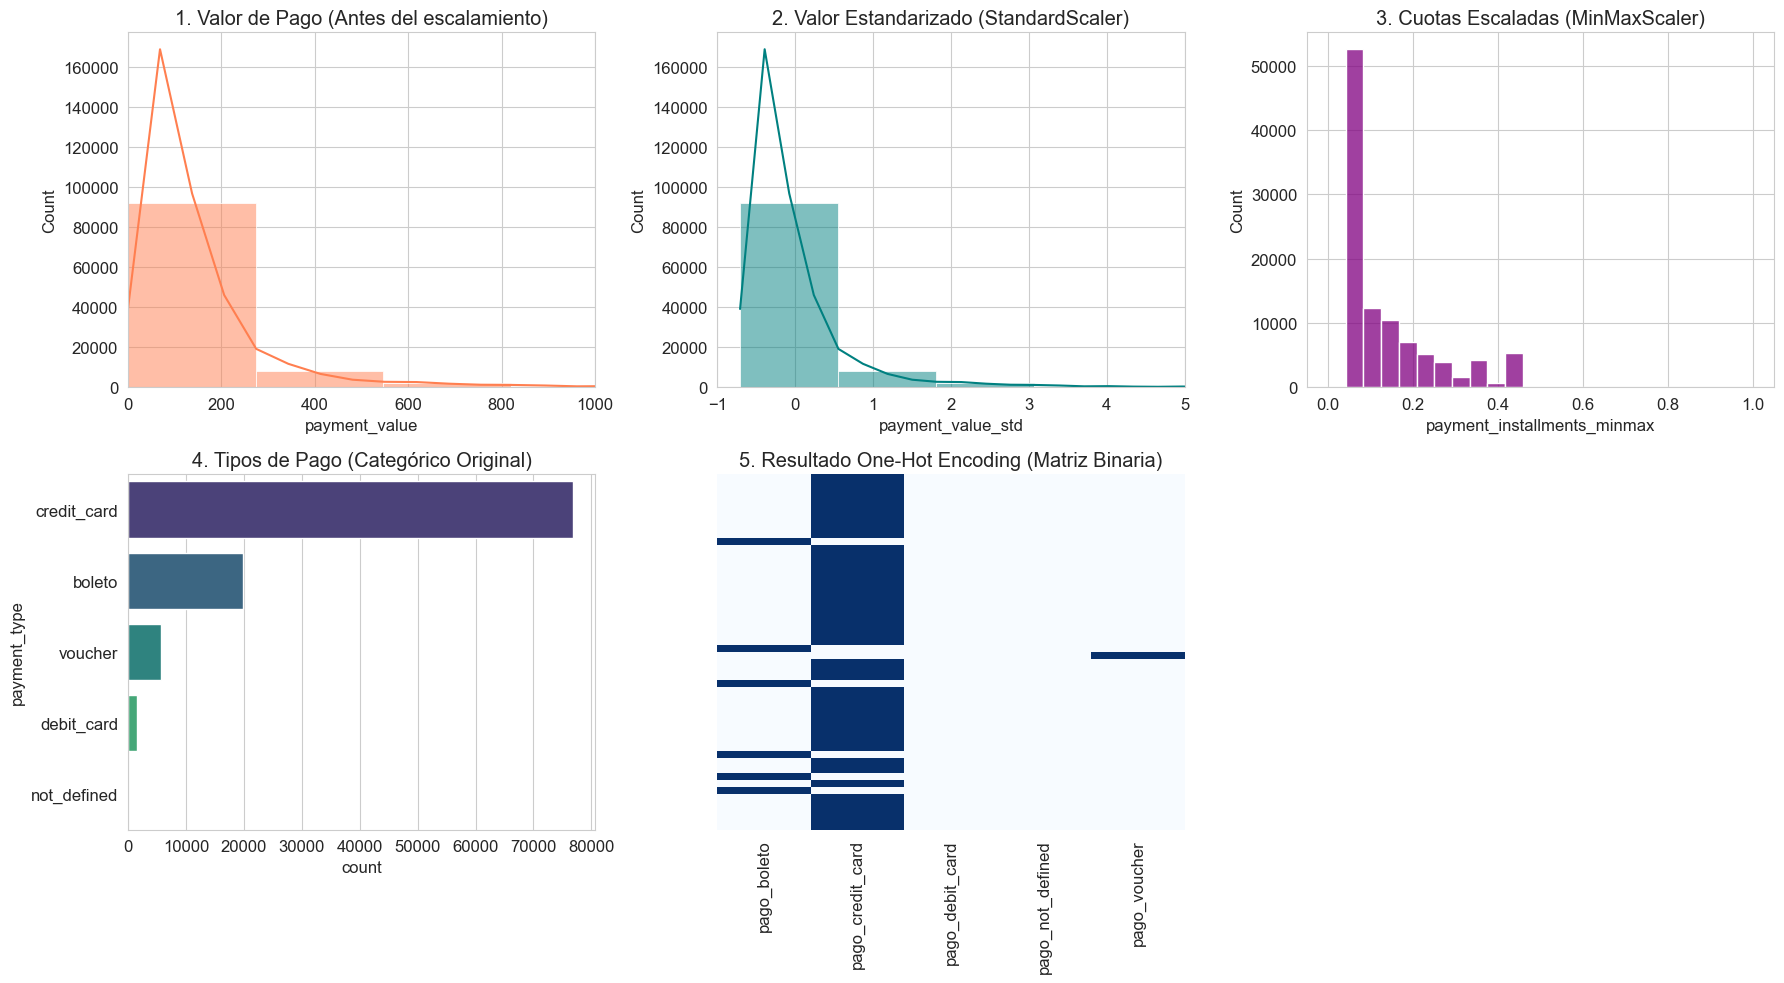

✅ Procesos aplicados correctamente.


In [11]:
df_transformado = df_pagos.copy()
valor_original = df_transformado['payment_value'].copy()

# ==========================================
# 1. APLICACIÓN DE ESCALAMIENTO
# ==========================================
# StandardScaler para el valor del pago
scaler_std = StandardScaler()
df_transformado['payment_value_std'] = scaler_std.fit_transform(df_transformado[['payment_value']])

# MinMaxScaler para las cuotas
scaler_minmax = MinMaxScaler()
df_transformado['payment_installments_minmax'] = scaler_minmax.fit_transform(df_transformado[['payment_installments']])

# ==========================================
# 2. APLICACIÓN DE CODIFICACIÓN
# ==========================================
# One-Hot Encoding para el tipo de pago
df_transformado = pd.get_dummies(df_transformado, columns=['payment_type'], prefix='pago', dtype=int)

# ==========================================
# 3. VISUALIZACIONES EXIGIDAS
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Gráfico 1: Valor de Pago (Original)
sns.histplot(valor_original, bins=50, color='coral', ax=axes[0, 0], kde=True)
axes[0, 0].set_title('1. Valor de Pago (Antes del escalamiento)')
axes[0, 0].set_xlim(0, 1000)

# Gráfico 2: Valor de Pago (StandardScaler)
sns.histplot(df_transformado['payment_value_std'], bins=50, color='teal', ax=axes[0, 1], kde=True)
axes[0, 1].set_title('2. Valor Estandarizado (StandardScaler)')
axes[0, 1].set_xlim(-1, 5)

# Gráfico 3: Cuotas (MinMaxScaler)
sns.histplot(df_transformado['payment_installments_minmax'], bins=24, color='purple', ax=axes[0, 2])
axes[0, 2].set_title('3. Cuotas Escaladas (MinMaxScaler)')

# Gráfico 4: Tipos de Pago Originales
sns.countplot(data=df_pagos, y='payment_type', ax=axes[1, 0], palette='viridis', order=df_pagos['payment_type'].value_counts().index)
axes[1, 0].set_title('4. Tipos de Pago (Categórico Original)')

# Gráfico 5: Matriz de One-Hot Encoding
columnas_dummy = [col for col in df_transformado.columns if 'pago_' in col]
sns.heatmap(df_transformado[columnas_dummy].head(50), cmap='Blues', cbar=False, ax=axes[1, 1], yticklabels=False)
axes[1, 1].set_title('5. Resultado One-Hot Encoding (Matriz Binaria)')

axes[1, 2].axis('off') # Ocultar gráfico vacío
plt.tight_layout()
plt.show()

print("✅ Procesos aplicados correctamente.")